# Cars4U Project

## Problem Statement 

### The purpose of this pricing model is to analyze the prices and other statistics of the cars at Cars4U via univariuate and multiavariate analysis and create a linear regression model to predict the prices and create a profile on how to sell the ideal car. Questions that will be answered include how the variables interact with each other to create the estimated price of a car and how we can use the linear regression model to sell cars at a profit for the company.

## Preparation of Dataset for Analysis

In [304]:
##Import necessary libraries
import numpy as np   
from sklearn.linear_model import LinearRegression
import pandas as pd    
import matplotlib.pyplot as plt 
%matplotlib inline 
import seaborn as sns
from sklearn.model_selection import train_test_split # Sklearn package"s randomized data splitting function

In [260]:
#Reads the csv file to create a dataframe
df = pd.read_csv("used_cars_data.csv")  

In [263]:
#Gives the total number of rows and columns
df.shape

(7253, 14)

In [262]:
#Confirmation of the successful reading of the dataframe"s top 5 rows
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,5.51,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,16.06,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,11.27,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,53.14,17.74


In [264]:
#Gives last 5 rows of dataset
df.tail()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
7248,7248,Volkswagen Vento Diesel Trendline,Hyderabad,2011,89411,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.0,13.23,NaN
7249,7249,Volkswagen Polo GT TSI,Mumbai,2015,59000,Petrol,Automatic,First,17.21 kmpl,1197 CC,103.6 bhp,5.0,10.15,NaN
7250,7250,Nissan Micra Diesel XV,Kolkata,2012,28000,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,9.47,NaN
7251,7251,Volkswagen Polo GT TSI,Pune,2013,52262,Petrol,Automatic,Third,17.2 kmpl,1197 CC,103.6 bhp,5.0,10.15,NaN
7252,7252,Mercedes-Benz E-Class 2009-2013 E 220 CDI Avan...,Kochi,2014,72443,Diesel,Automatic,First,10.0 kmpl,2148 CC,170 bhp,5.0,86.97,NaN


In [265]:
#Gives total number of entries and data types of each column.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   object 
 9   Engine             7207 non-null   object 
 10  Power              7078 non-null   object 
 11  Seats              7200 non-null   float64
 12  New_Price          7253 non-null   float64
 13  Price              6019 non-null   float64
dtypes: float64(3), int64(3), object(8)
memory usage: 793.4+ KB


In [15]:
#Gives basic statistics of the dataset, including quartiles, mean, minimum, maximum, etc. 
df.describe(include = "all")

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
count,7253.000000,7253,7253,7253.000000,7.253000e+03,7253,7253,7253,7251,7207,7078,7200.000000,7253.000000,6019.000000
unique,NaN,2041,11,NaN,NaN,5,2,4,450,150,385,NaN,NaN,NaN
top,NaN,Mahindra XUV500 W8 2WD,Mumbai,NaN,NaN,Diesel,Manual,First,17.0 kmpl,1197 CC,74 bhp,NaN,NaN,NaN
freq,NaN,55,949,NaN,NaN,3852,5204,5952,207,732,280,NaN,NaN,NaN
mean,3626.000000,NaN,NaN,2013.365366,5.869906e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.279722,21.307322,9.479468
std,2093.905084,NaN,NaN,3.254421,8.442772e+04,NaN,NaN,NaN,NaN,NaN,NaN,0.811660,24.256314,11.187917
min,0.000000,NaN,NaN,1996.000000,1.710000e+02,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3.910000,0.440000
25%,1813.000000,NaN,NaN,2011.000000,3.400000e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,7.880000,3.500000
50%,3626.000000,NaN,NaN,2014.000000,5.341600e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,11.300000,5.640000
75%,5439.000000,NaN,NaN,2016.000000,7.300000e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,21.690000,9.950000


In [266]:
#Give columns of dataframe
df.columns

Index(['S.No.', 'Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'New_Price', 'Price'],
      dtype='object')

In [21]:
#Search for any duplicated values in the data frame
df.duplicated().sum()

0

In [22]:
#Checking for missing values
df.isnull().sum().sort_values(ascending=False)

Price                1234
Power                 175
Seats                  53
Engine                 46
Mileage                 2
S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
New_Price               0
dtype: int64

In [16]:
#Number of unique variables in dataframe
df.nunique()

S.No.                7253
Name                 2041
Location               11
Year                   23
Kilometers_Driven    3660
Fuel_Type               5
Transmission            2
Owner_Type              4
Mileage               450
Engine                150
Power                 385
Seats                   9
New_Price             643
Price                1373
dtype: int64

In [27]:
#Let"s make a loop to find the unique categorical values in each column

cat_value = ["Location", "Seats", "Year", "Transmission", "Owner_Type", "Fuel_Type"]

for column in cat_value:
    print(df[column].value_counts())
    print("/n")

Mumbai        949
Hyderabad     876
Coimbatore    772
Kochi         772
Pune          765
Delhi         660
Kolkata       654
Chennai       591
Jaipur        499
Bangalore     440
Ahmedabad     275
Name: Location, dtype: int64
/n
5.0     6047
7.0      796
8.0      170
4.0      119
6.0       38
2.0       18
10.0       8
9.0        3
0.0        1
Name: Seats, dtype: int64
/n
2015    929
2014    925
2016    886
2013    791
2017    709
2012    690
2011    579
2010    407
2018    361
2009    252
2008    207
2007    148
2019    119
2006     89
2005     68
2004     35
2003     20
2002     18
2001      8
2000      5
1998      4
1999      2
1996      1
Name: Year, dtype: int64
/n
Manual       5204
Automatic    2049
Name: Transmission, dtype: int64
/n
First             5952
Second            1152
Third              137
Fourth & Above      12
Name: Owner_Type, dtype: int64
/n
Diesel      3852
Petrol      3325
CNG           62
LPG           12
Electric       2
Name: Fuel_Type, dtype: int64
/n


## Data Preprocessing

### Let"s find and rearrange the missing variables in the columns

In [267]:
df[["Power", "Seats", "Engine", "Mileage"]].sample(25) #Pulls random sample from the given columns

,Power,Seats,Engine,Mileage
4925,147.5 bhp,5.0,2179 CC,12.83 kmpl
5956,100 bhp,7.0,2494 CC,12.99 kmpl
899,158.2 bhp,5.0,2494 CC,19.16 kmpl
2168,73.9 bhp,5.0,1198 CC,16.47 kmpl
401,175.56 bhp,7.0,2477 CC,13.5 kmpl
37,82 bhp,5.0,1198 CC,18.15 kmpl
5047,74 bhp,5.0,1248 CC,22.9 kmpl
5459,258 bhp,5.0,2987 CC,13.0 kmpl
2056,261.49 bhp,5.0,2993 CC,16.77 kmpl
2284,174.33 bhp,5.0,1968 CC,17.11 kmpl


### We"re seeing several NaN values as well as 0.0 kmpl in the Mileage column. Let"s remove their units for now. We will address the NaN and 0 values when we handle missing values.


In [63]:
df["Mileage"] = df["Mileage"].str.rstrip(" kmpl") #Remove units

In [64]:
df["Engine"] = df["Engine"].str.rstrip(" CC") #Remove units

In [65]:
df["Power"] = df["Power"].str.rstrip(" bhp") #Remove units

In [66]:
df[["Power", "Seats", "Engine", "Mileage"]].sample(25) #Verify the data

,Power,Seats,Engine,Mileage
5258,98.6,5.0,1498,26.0
2242,174.5,7.0,2755,14.24
187,83.1,5.0,1197,21.4
6209,184,5.0,1995,17.05
3731,108.5,5.0,1461,19.64
2167,118,5.0,1497,16.8
455,47,5.0,793,27.62
702,82,5.0,1197,18.9
6833,140,7.0,2179,16.0
6711,81.80,5.0,1197,20.4


### Let"s convert the 0 values in mileage to NaN and address them later with the rest of the missing values

In [268]:
df.loc[df["Mileage"] == "0.0", "Mileage"] = np.nan #Convert values to NaN
df.isnull().sum() #Gives sum of the null values in the dataframe

S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                 175
Seats                  53
New_Price               0
Price                1234
dtype: int64

### Do Seats have any 0 values? What about Price? Let"s see

In [69]:
df.query("Seats == 0.0")["Seats"]

3999    0.0
Name: Seats, dtype: float64

In [70]:
df.query("Price == 0.0")["Price"]

Series([], Name: Price, dtype: float64)

### Seats does so let"s change it to NaN and address it later

In [269]:
df.loc[3999, "Seats"] = np.nan #Convert values to NaN

## Feature Engineering


In [270]:
df.describe().T #Receive the exact values for the mean and percentiles 

,count,mean,std,min,25%,50%,75%,max
S.No.,7253.0,3626.000000,2093.905084,0.00,1813.00,3626.00,5439.00,7252.0
Year,7253.0,2013.365366,3.254421,1996.00,2011.00,2014.00,2016.00,2019.0
Kilometers_Driven,7253.0,58699.063146,84427.720583,171.00,34000.00,53416.00,73000.00,6500000.0
Seats,7199.0,5.280456,0.809327,2.00,5.00,5.00,5.00,10.0
New_Price,7253.0,21.307322,24.256314,3.91,7.88,11.30,21.69,375.0
Price,6019.0,9.479468,11.187917,0.44,3.50,5.64,9.95,160.0


### Let"s change year to age of cars. That way we can properly understand the effect age has on the price of used cars.


In [271]:
df["PresentYear"] = 2022 #Assign value for the current year
df["Age"] = df["PresentYear"] - df["Year"] #Assign new column based on the difference between the current year and the manufactured year
df.drop("PresentYear", axis = 1, inplace = True) #Drop present year column
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Age
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,5.51,1.75,12
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,16.06,12.50,7
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61,4.50,11
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,11.27,6.00,10
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,53.14,17.74,9


### Now let"s focus on the names of the cars. Note that there are over 2000 unique names for the cars. Are there really 2000 different car brands out there? Of course not! Let"s fix this


In [83]:
df["Brand"] = df["Name"].str.split(" ").str[0] #Separating Brand name from the Name

df.Brand.unique() #Finding unique values for the Brand names

array(['Maruti', 'Hyundai', 'Honda', 'Audi', 'Nissan', 'Toyota',
       'Volkswagen', 'Tata', 'Land', 'Mitsubishi', 'Renault',
       'Mercedes-Benz', 'BMW', 'Mahindra', 'Ford', 'Porsche', 'Datsun',
       'Jaguar', 'Volvo', 'Chevrolet', 'Skoda', 'Mini', 'Fiat', 'Jeep',
       'Smart', 'Ambassador', 'Isuzu', 'ISUZU', 'Force', 'Bentley',
       'Lamborghini', 'Hindustan', 'OpelCorsa'], dtype=object)

### Note that Isuzu and ISUZU are the same brand. Let"s change them to become one brand

In [84]:
df.loc[df.Brand == "ISUZU", "Brand"] = "Isuzu"
df.Brand.nunique() #Finding unique number of values for the Brand names

32

In [86]:
df.groupby(df.Brand).size().sort_values(ascending = False) #Group cars by brand and discover most common brand that is purchased

Brand
Maruti           1444
Hyundai          1340
Honda             743
Toyota            507
Mercedes-Benz     380
Volkswagen        374
Ford              351
Mahindra          331
BMW               312
Audi              285
Tata              228
Skoda             202
Renault           170
Chevrolet         151
Nissan            117
Land               67
Jaguar             48
Fiat               38
Mitsubishi         36
Mini               31
Volvo              28
Jeep               19
Porsche            19
Datsun             17
Isuzu               5
Force               3
Bentley             2
Lamborghini         1
OpelCorsa           1
Hindustan           1
Smart               1
Ambassador          1
dtype: int64

In [87]:
df.groupby(df.Model).size().sort_values(ascending = False) #Group cars by model and discover most common model that is purchased

Model
SwiftDzire     189
Grandi10       179
WagonR         178
Innova2.5      145
Verna1.6       127
              ... 
DzireNew         1
SL-ClassSL       1
SLK-Class55      1
DusterRXZ        1
1000AC           1
Length: 726, dtype: int64

In [89]:
df.Model.nunique() #Finding unique number of values for the Model names

726

In [90]:
df.Model.isnull().sum() #Finding  number of null values for the Model names

1

In [91]:
df.dropna(subset=["Model"],axis=0,inplace=True) #Drop the roow with no model in it

### There are 32 unique brands and 726 unique models in this dataset. Maruti and Hyundai are the most common cars available in the dataset and the SwiftDzire is the most common model in the dataset

## Exploratory Data Analysis

### Univariate Analysis 

#### Let"s use a loop to create several charts at once to observe 

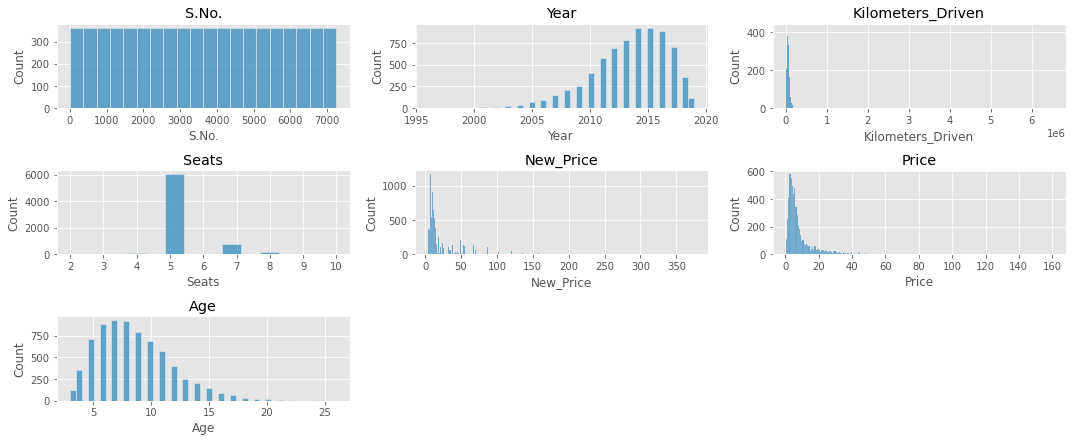

In [108]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist() #Variable to be used in the for loop
plt.figure(figsize=(15 ,20)) 

for i, variable in enumerate(numeric_columns): #for loop to form several histograms
                     plt.subplot(10,3,i+1)
                       
                     sns.histplot(df[variable],kde=False)
                     plt.title(variable) #Displays title
                     plt.tight_layout() #Properly formats the charts so taht the titles do not overlap 

#### We can see the right skew of the manufacture years of the cars in the dataset, with a few outliers in the lower years. It is the opposite for the age of the cars, as that value is a direct negative correlation to the manufacture year. Price and kilometers driven also skew right. 

#### Price is the most important variable in the set. Let"s analyze that

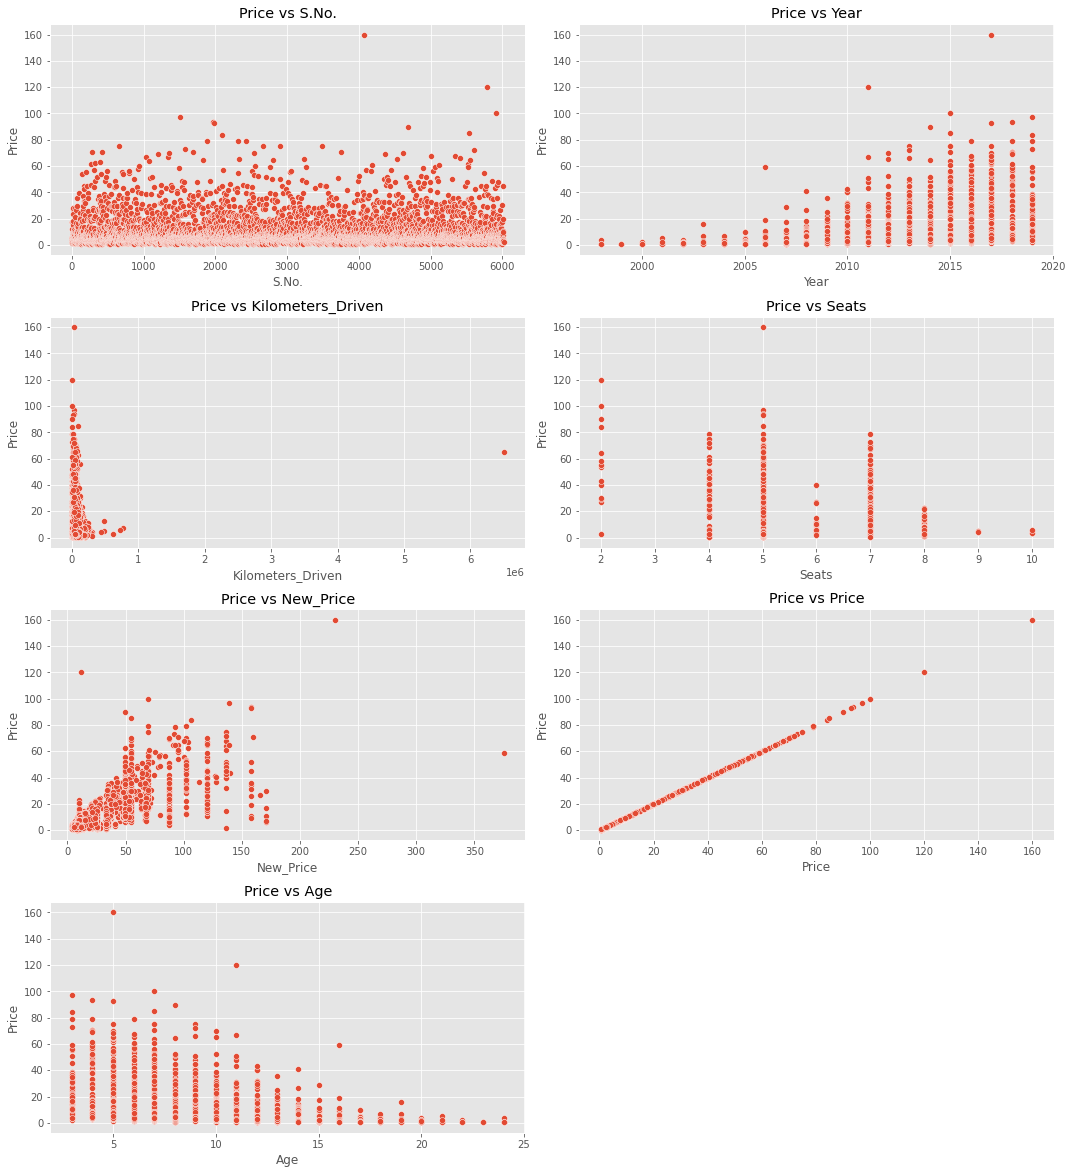

In [124]:
plt.figure(figsize=(15,20))

for i, variable in enumerate(numeric_columns):
           plt.subplot(5,2,i+1)
           sns.scatterplot(x=df[variable],y=df["Price"]).set(title="Price vs "+ variable)
           plt.tight_layout()

#### Based off the graphs, we can say that the price of a car is directly correlated to the year and inversely related to age. Other variables do not exhibit such a strong correlation

#### Let"s observe the counts of the categorical variables present in the dataset 

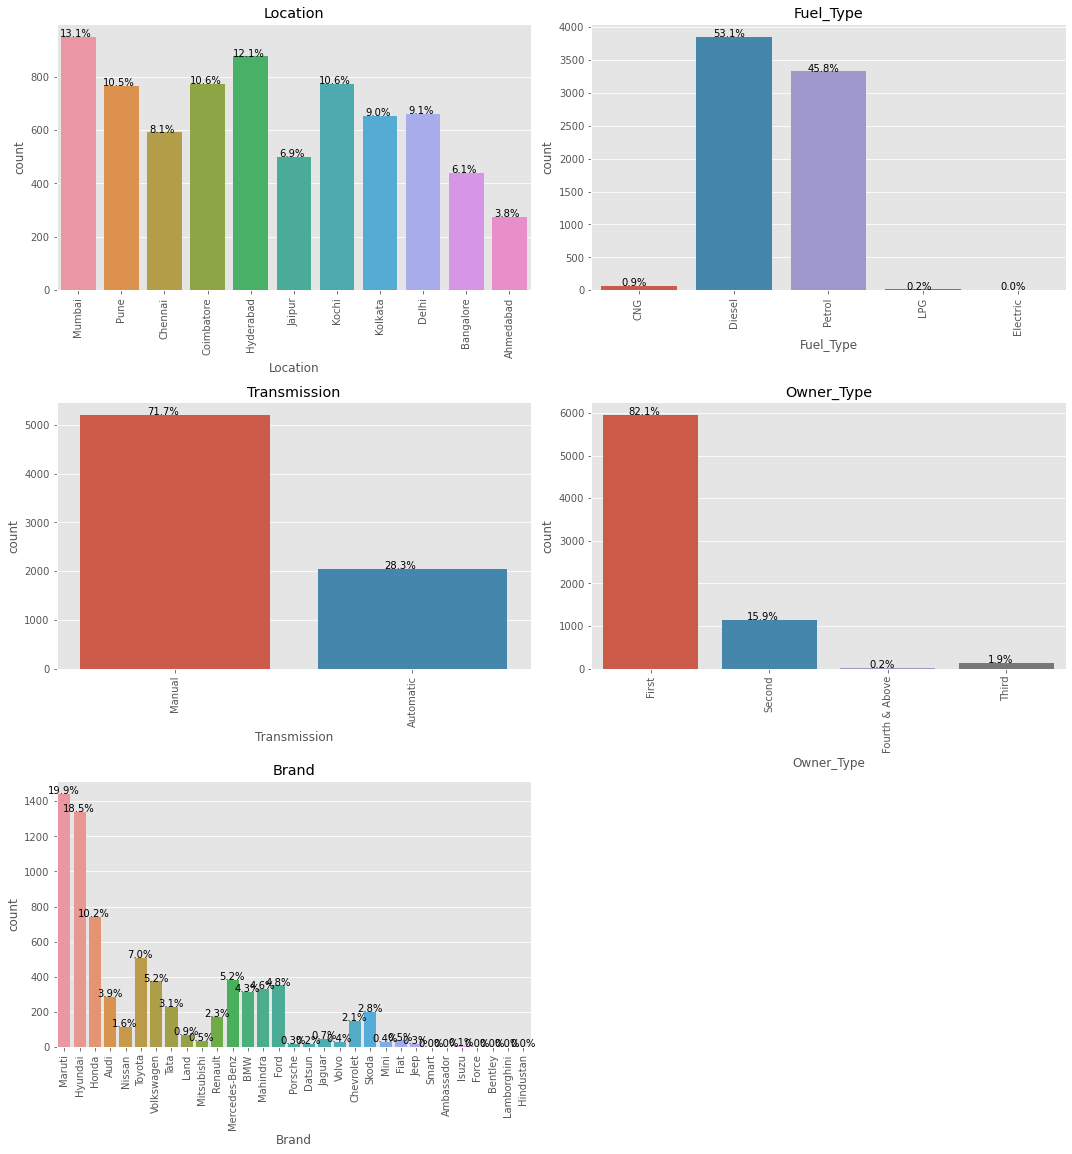

In [128]:
catcol=["Location","Fuel_Type","Transmission", "Owner_Type", "Brand"]

plt.figure(figsize=(15,20))

for i, variable in enumerate(catcol):
                     plt.subplot(4,2,i+1)
                     order = df[variable].value_counts(ascending=False).index    
                     ax=sns.countplot(x=df[variable], data=df)
                     for p in ax.patches:
                           percentage = "{:.1f}%".format(100 * p.get_height()/len(df[variable]))
                           x = p.get_x() + p.get_width() / 2 - 0.05
                           y = p.get_y() + p.get_height()
                           plt.annotate(percentage, (x, y),ha="center")
                     plt.tight_layout()
                     plt.title(variable)
                     plt.xticks(rotation=90)

#### Mumbai has the highest percentage of cars available while Ahmedabad has the least. The vast majority of the cars are manual cars. A large portion are also first owned cars. Interstingly, the majority of the cars use diesel as opposed to petrol.

### Bivariate Analysis 

<AxesSubplot:>

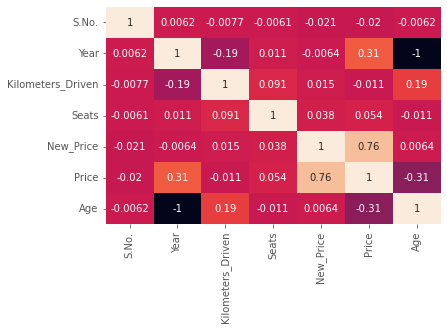

In [183]:
#Heatmap to see the correlations between the variables
corrmap = df.corr()
sns.heatmap(corrmap, annot =True, cbar = False)

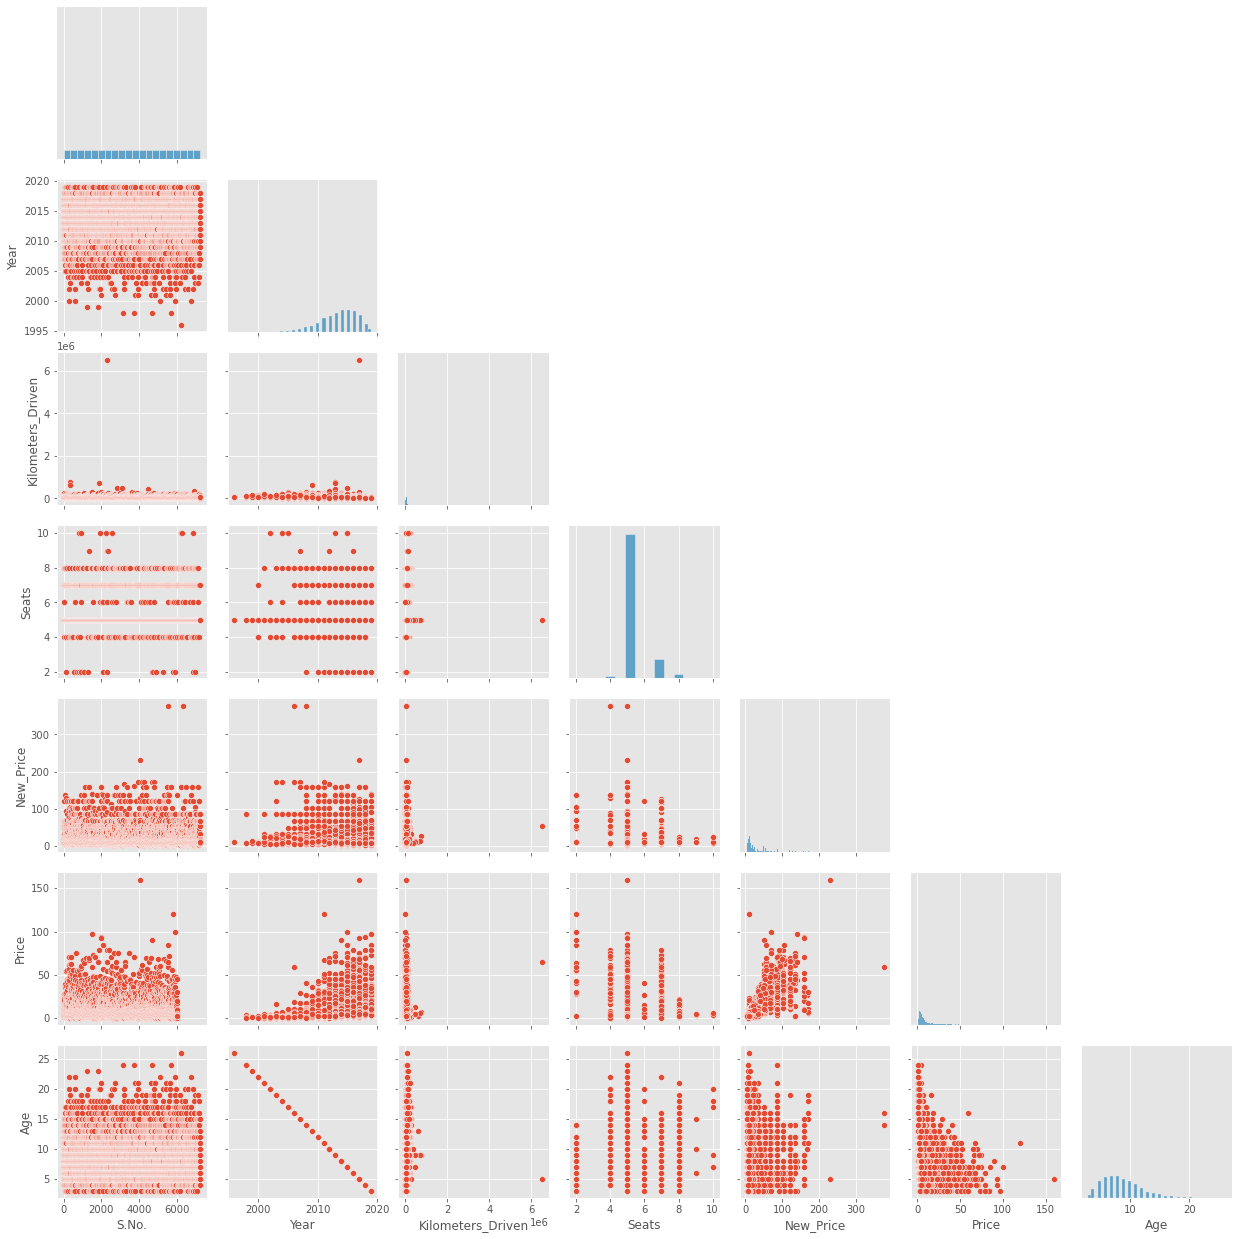

In [187]:
#Pair plot to show the correlations we noticed from the heatmap in graph form
sns.pairplot(data = df , corner=True)
plt.show()

#### The main variable to observe is price

<AxesSubplot:title={'center':'Price Vs Mileage'}, xlabel='Mileage', ylabel='Price'>

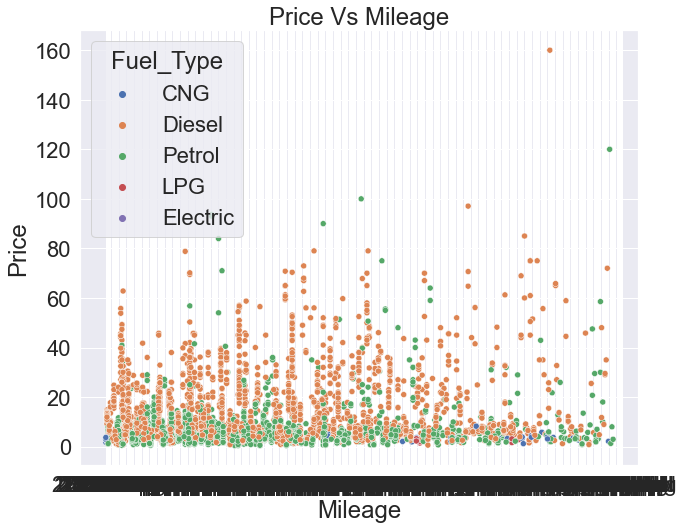

In [274]:
# Understand relationships between price and mileage
plt.figure(figsize=(10,8))
plt.title("Price Vs Mileage")
sns.scatterplot(data=df, x="Mileage", y="Price", hue="Fuel_Type", )

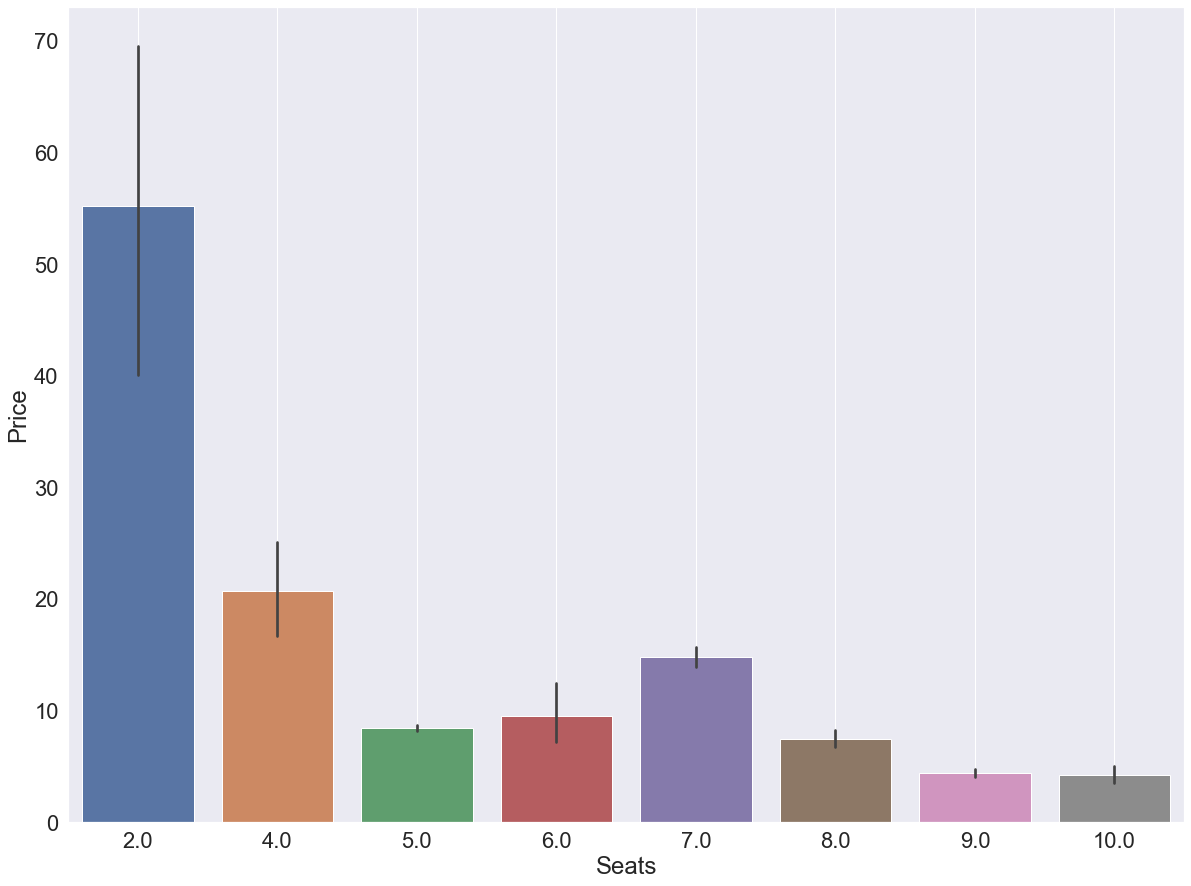

In [204]:
#Understand relationships between price and seats
plt.figure(figsize=(20,15))
sns.set(font_scale=2)
sns.barplot(data=df, x="Seats", y="Price")
plt.grid()

#### It seems that the expensive cars tend to have 2 seats while cheaper cars have more. This could mean that family cars are cheaper as they tend to have more doors to allow more people to ride

<AxesSubplot:xlabel='Location', ylabel='Price'>

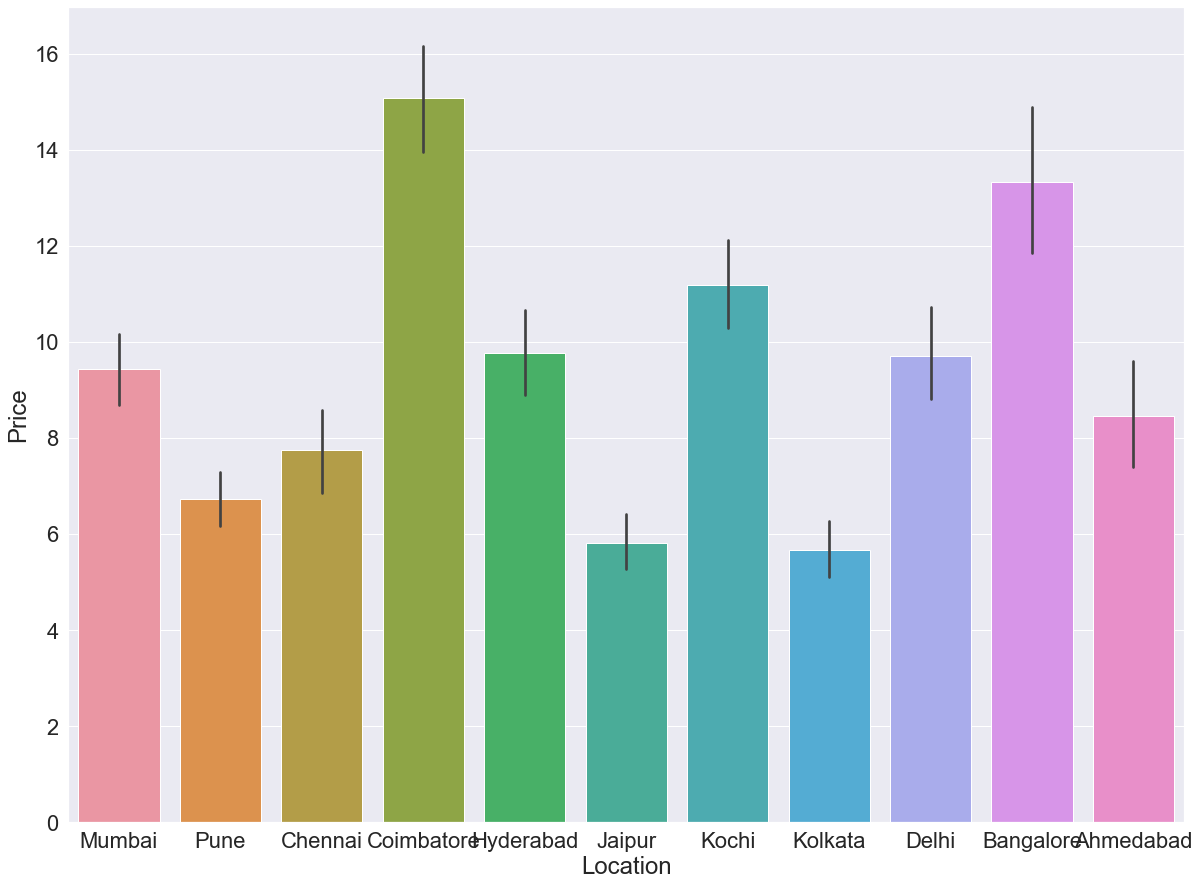

In [275]:
#Understand relationships between price and location
plt.figure(figsize=(20,15))
sns.set(font_scale=2)
sns.barplot(data=df, x="Location", y="Price")

#### Coimbatore and Bangalore have the most expensive cars. They are large cities, cities like Chennai and Mumbai are also large but do not share the same average price. More research should be performed. 

<AxesSubplot:title={'center':'Price Vs Year VS FuelType'}, xlabel='Year', ylabel='Price'>

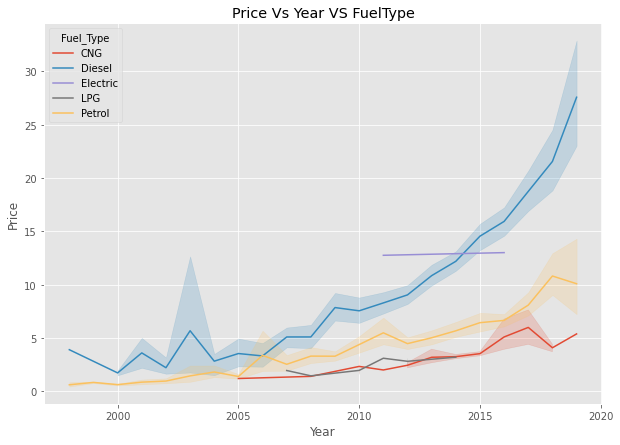

In [199]:
#Understand relationships between price, year, and fuel type
plt.figure(figsize=(10,7))
plt.title("Price Vs Year VS FuelType")
sns.lineplot(data=df, x="Year", y="Price",hue="Fuel_Type")

#### Diesel cars are signifigantly more expensive than petrol and CNG cars 

<AxesSubplot:title={'center':'Price Vs Year VS Owner_Type'}, xlabel='Year', ylabel='Price'>

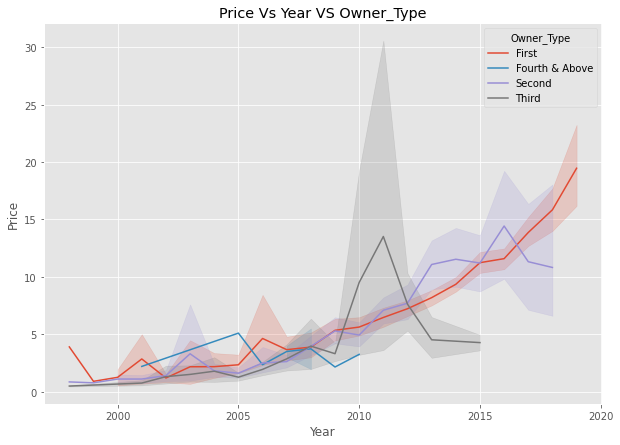

In [200]:
#Understand relationships between price, year, and owner type
plt.figure(figsize=(10,7))
plt.title("Price Vs Year VS Owner_Type")
sns.lineplot(data=df, x="Year", y="Price",hue="Owner_Type")

#### Recent first owner cars  tend to be the most expensive while second owned cares from the early 2010s hold a middle ground. Older cars from all sorts of owners make up the cheaper end of the cars in the dataframe.

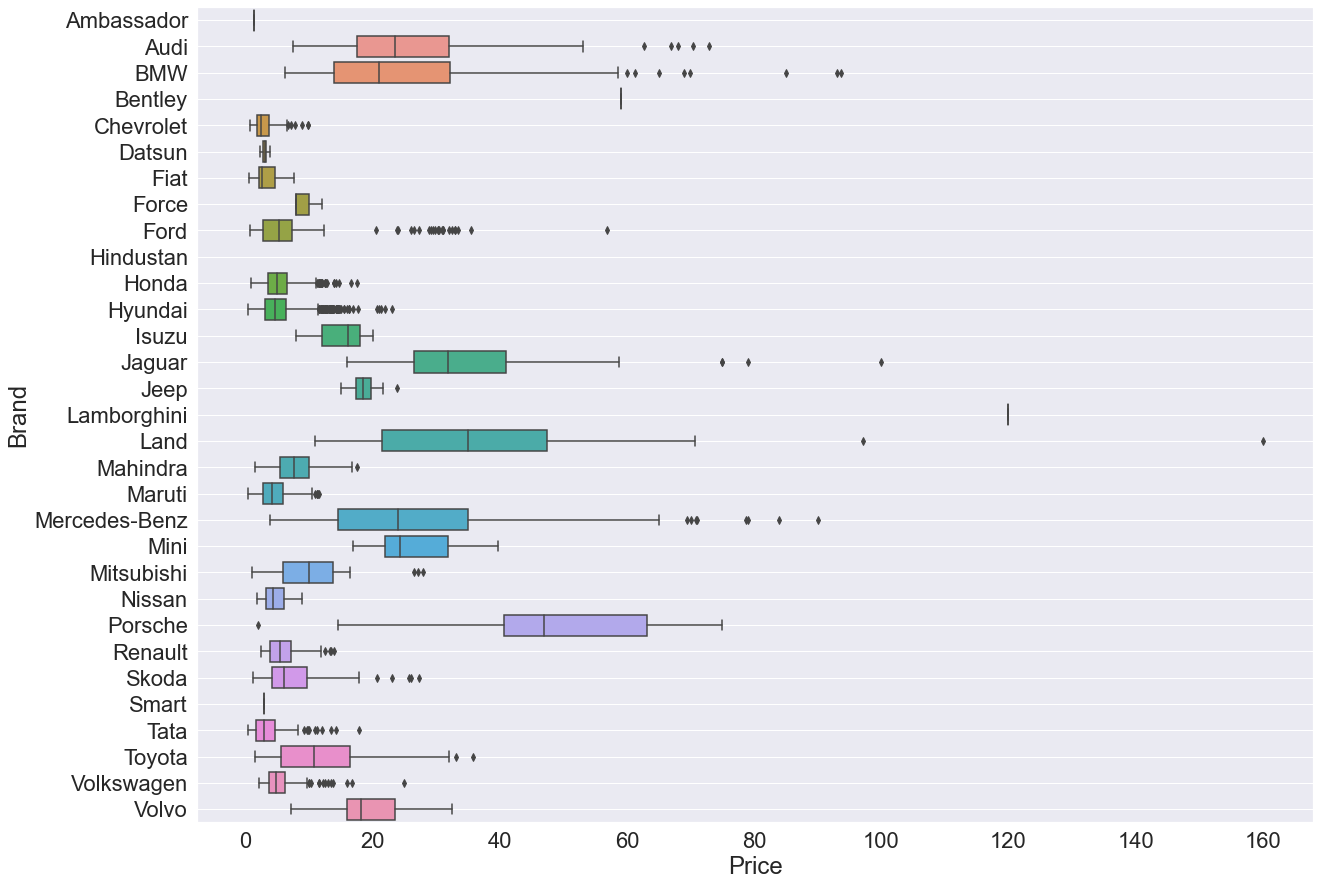

In [206]:
#Understand relationships between price and brand
plt.figure(figsize=(20,15))
sns.set(font_scale=2)
sns.boxplot(data=df, x="Price", y="Brand")
plt.grid()

#### On average, Land Rovers tend to be the most expensive cars, with a single outlier being the most expensive car in the dataset. Lamborghinis are also incredibly expensive but they make up a very small portion of the data. Tata and Chevrolet appear to be the cheapest cars on average. 

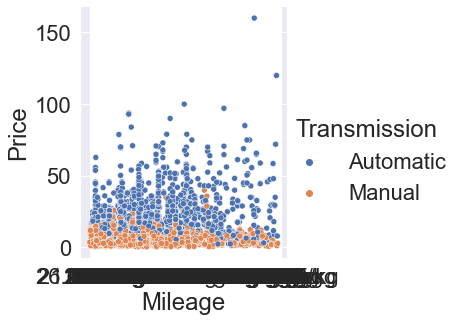

In [209]:
#Understand relationships between price, mileage, and transmission
sns.relplot(data=df, x="Mileage", y="Price",hue="Transmission",aspect=1,height=5)

#### Automatic cars tend to be more expensive than manuals. Transmission does not play a major role in the mileage of a car. 

## Addressing Missing Values 

In [294]:
##Find the total number of missing values in each category for the set
df.isnull().sum()

S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                 175
Seats                  54
New_Price               0
Price                1234
Age                     0
dtype: int64

### Let"s use another loop to find the missing values in each row 

In [305]:
missing = df.isnull().sum(axis=1)

for n in missing.value_counts().sort_index().index:
    if n > 0:
        print("*" *30,f"\nFor the rows with exactly {n} missing values, NAs are found in:")
        n_miss_per_col = df[missing == n].isnull().sum()
        print(n_miss_per_col[n_miss_per_col > 0])
        print("\n\n")

****************************** 
For the rows with exactly 1 missing values, NAs are found in:
Mileage       2
Power       102
Seats         2
Price      1201
dtype: int64



****************************** 
For the rows with exactly 2 missing values, NAs are found in:
Power    27
Seats     6
Price    23
dtype: int64



****************************** 
For the rows with exactly 3 missing values, NAs are found in:
Engine    36
Power     36
Seats     36
dtype: int64



****************************** 
For the rows with exactly 4 missing values, NAs are found in:
Engine    10
Power     10
Seats     10
Price     10
dtype: int64





### There are some columns that are missing. Let"s fill them in. 

In [306]:
df[missing == 4]

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Age
6042,6042,Skoda Laura 1.8 TSI Ambition,Bangalore,2009,72000,Petrol,Manual,Second,17.5 kmpl,NaN,NaN,NaN,25.830,NaN,13
6541,6541,Toyota Etios Liva Diesel TRD Sportivo,Bangalore,2012,56600,Diesel,Manual,First,23.59 kmpl,NaN,NaN,NaN,8.525,NaN,10
6544,6544,Hyundai i20 new Sportz AT 1.4,Bangalore,2012,58000,Petrol,Automatic,Second,15.0 kmpl,NaN,NaN,NaN,10.250,NaN,10
6633,6633,Mahindra TUV 300 P4,Kolkata,2016,27000,Diesel,Manual,First,0.0 kmpl,NaN,NaN,NaN,18.865,NaN,6
6643,6643,BMW 5 Series 520d Sedan,Bangalore,2009,150000,Diesel,Automatic,Second,18.48 kmpl,NaN,NaN,NaN,67.870,NaN,13
6651,6651,Maruti Swift 1.3 VXi,Kolkata,2015,36009,Petrol,Manual,First,16.1 kmpl,NaN,NaN,NaN,7.880,NaN,7
6677,6677,Fiat Punto 1.4 Emotion,Jaipur,2010,65000,Petrol,Manual,Third,14.6 kmpl,NaN,NaN,NaN,8.600,NaN,12
6685,6685,Maruti Swift 1.3 VXi,Pune,2010,115000,Petrol,Manual,Second,16.1 kmpl,NaN,NaN,NaN,7.880,NaN,12
6880,6880,BMW 5 Series 520d Sedan,Chennai,2009,95000,Diesel,Automatic,Second,18.48 kmpl,NaN,NaN,NaN,67.870,NaN,13
6902,6902,Toyota Etios Liva V,Kochi,2012,59311,Petrol,Manual,First,18.3 kmpl,NaN,NaN,NaN,8.525,NaN,10


In [307]:
#Get a count of the missing variables in the set
var=["Engine","Power","Mileage"]
df[var].isnull().sum()

Engine      46
Power      175
Mileage      2
dtype: int64

### We can start filling in missing values by calling and grouping the names and years with median values

In [ ]:
df.groupby(["Name", "Year"])["Engine"].median().head()

In [ ]:
df["Engine"]=df.groupby(["Name","Year"])["Engine"].apply(lambda x:x.fillna(x.median()))
df["Power"]=df.groupby(["Name","Year"])["Power"].apply(lambda x:x.fillna(x.median()))
df["Mileage"]=df.groupby(["Name","Year"])["Mileage"].apply(lambda x:x.fillna(x.median()))

In [308]:
#Get a count of the missing variables in the set
var=["Engine","Power","Mileage"]
df[var].isnull().sum()

Engine      46
Power      175
Mileage      2
dtype: int64

### We can also fill in missing values of other variables with median values

In [145]:
df.groupby(["Brand", "Model"])["Engine"].median().head()

Brand       Model      
Ambassador  ClassicNova    1489.0
Audi        A335           1968.0
            A41.8          1781.0
            A42.0          1968.0
            A43.0          2967.0
Name: Engine, dtype: float64

In [149]:
df["Engine"]=df.groupby(["Brand","Model"])["Engine"].apply(lambda x:x.fillna(x.median()))

In [150]:
df["Power"]=df.groupby(["Brand","Model"])["Power"].apply(lambda x:x.fillna(x.median()))

In [ ]:
df["Mileage"]=df.groupby(["Brand","Model"])["Mileage"].apply(lambda x:x.fillna(x.median()))

In [303]:
df[var].isnull().sum()

Engine      46
Power      175
Mileage      2
dtype: int64

### Seats can be filled based on mode because taking a mean or median wouldnt make sense for this variable

In [309]:
df["Seats"].isnull().sum()

54

In [158]:
df["Seats"]=df.groupby(["Name"])["Seats"].apply(lambda x:x.fillna(x.median()))

In [159]:
df["Seats"].isnull().sum()

47

In [161]:
df["Seats"]=df.groupby(["Model"])["Seats"].apply(lambda x:x.fillna(x.median()))

In [162]:
df["Seats"].isnull().sum()

23

In [163]:
df[df["Seats"].isnull()==True].head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Age,Brand,Model
208,208,Maruti Swift 1.3 VXi,Kolkata,2010,42001,Petrol,Manual,First,16.1,NaN,NaN,NaN,7.88,2.11,12,Maruti,Swift1.3
733,733,Maruti Swift 1.3 VXi,Chennai,2006,97800,Petrol,Manual,Third,16.1,NaN,NaN,NaN,7.88,1.75,16,Maruti,Swift1.3
1327,1327,Maruti Swift 1.3 ZXI,Hyderabad,2015,50295,Petrol,Manual,First,16.1,NaN,NaN,NaN,7.88,5.80,7,Maruti,Swift1.3
2074,2074,Maruti Swift 1.3 LXI,Pune,2011,24255,Petrol,Manual,First,16.1,NaN,NaN,NaN,7.88,3.15,11,Maruti,Swift1.3
2325,2325,Maruti Swift 1.3 VXI ABS,Pune,2015,67000,Petrol,Manual,First,16.1,NaN,NaN,NaN,7.88,4.70,7,Maruti,Swift1.3


### Most of the cars are 5 seaters so fill the rest of the 23 rows with 5

In [164]:
#most of cars are 5 seater so fillrest of 23 by 5
df["Seats"]=df["Seats"].fillna(5)

In [165]:
df["Seats"].isnull().sum()

0

In [166]:
df["Location"] = df["Location"].astype("category")
df["Brand"] =df["Brand"].astype("category")

In [310]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   object 
 9   Engine             7207 non-null   object 
 10  Power              7078 non-null   object 
 11  Seats              7199 non-null   float64
 12  New_Price          7253 non-null   float64
 13  Price              6019 non-null   float64
 14  Age                7253 non-null   int64  
dtypes: float64(3), int64(4), object(8)
memory usage: 850.1+ KB


## Outliers and Log Transformation

### Let"s check to see if the distribution is skewed. If the data is skewed, we will have to use log transformation to reduce it and create a more normalized dataset 

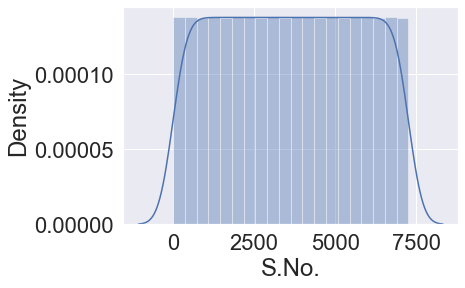

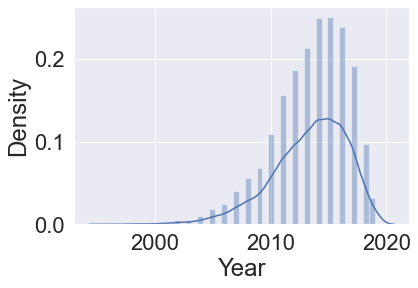

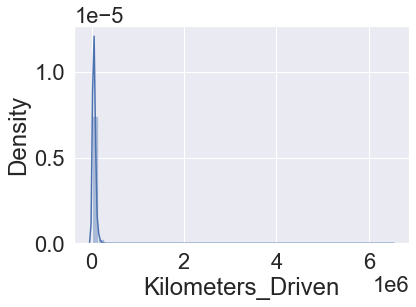

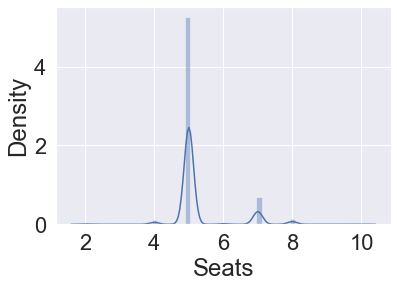

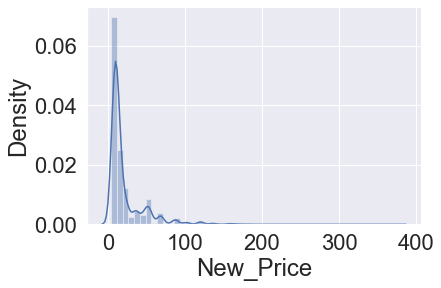

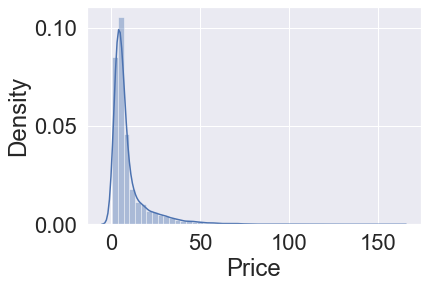

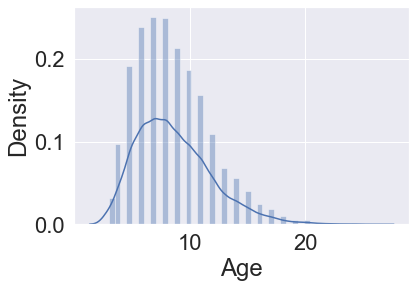

In [212]:
#For loop to call all the posssible histograms to be observed for skew
cols_to_log = df.select_dtypes(include=np.number).columns.tolist()
for colname in cols_to_log:
    sns.histplot(df[colname], kde=True)
    plt.show()

### There is right skew on several of these histograms, so we must use log transformation 

In [219]:
#Lists columns and performs log transformation on the dataset

def log_normalize (df, col_log):
    for colname in col_log:
        df[colname + "_log"] = np.log(df[colname])
    #df.drop(col_log, axis=1, inplace=True)
    df.info()

log_normalize(df,["Kilometers_Driven","Price"])

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7252 entries, 0 to 7252
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   S.No.                  7252 non-null   int64   
 1   Name                   7252 non-null   object  
 2   Location               7252 non-null   category
 3   Year                   7252 non-null   int64   
 4   Kilometers_Driven      7252 non-null   int64   
 5   Fuel_Type              7252 non-null   category
 6   Transmission           7252 non-null   category
 7   Owner_Type             7252 non-null   category
 8   Mileage                7169 non-null   object  
 9   Engine                 7234 non-null   object  
 10  Power                  7189 non-null   object  
 11  Seats                  7252 non-null   float64 
 12  New_Price              7252 non-null   float64 
 13  Price                  6019 non-null   float64 
 14  Age                    7252 non-null   i

In [221]:
df.drop(["Name","Model","Year","Brand"],axis=1,inplace=True) #Drop these rows

In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7252 entries, 0 to 7252
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   S.No.                  7252 non-null   int64   
 1   Location               7252 non-null   category
 2   Kilometers_Driven      7252 non-null   int64   
 3   Fuel_Type              7252 non-null   category
 4   Transmission           7252 non-null   category
 5   Owner_Type             7252 non-null   category
 6   Mileage                7169 non-null   object  
 7   Engine                 7234 non-null   object  
 8   Power                  7189 non-null   object  
 9   Seats                  7252 non-null   float64 
 10  New_Price              7252 non-null   float64 
 11  Price                  6019 non-null   float64 
 12  Age                    7252 non-null   int64   
 13  Kilometers_Driven_log  7252 non-null   float64 
 14  Price_log              6019 non-null   f

## Linear Regression 

In [248]:
##Model Building

X = df.drop(["Price", "Price_log"], axis=1)
y = df[["Price_log", "Price"]]

In [249]:
#Creating dummy variables
def encode_cat_vars(x):
    x = pd.get_dummies(
        x,
        columns=x.select_dtypes(include=["object", "category"]).columns.tolist(),
        drop_first=True,
    )
    return x

In [250]:
X = encode_cat_vars(X)
X.head()

,S.No.,Kilometers_Driven,Seats,New_Price,Age,Kilometers_Driven_log,Location_Bangalore,Location_Chennai,Location_Coimbatore,Location_Delhi,...,Power_97.6,Power_97.7,Power_98.59,Power_98.6,Power_98.63,Power_98.79,Power_98.82,Power_98.96,Power_99,Power_99.6
0,0,72000,5.0,5.51,12,11.184421,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,41000,5.0,16.06,7,10.621327,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,46000,5.0,8.61,11,10.736397,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,87000,7.0,11.27,10,11.373663,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,40670,5.0,53.14,9,10.613246,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [251]:
#Form test and train data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
X_train.reset_index()
print("X_train:",X_train.shape)
print("X_test:",X_test.shape)
print("y_train:",y_train.shape)

print("y_test:",y_test.shape)

X_train: (5076, 1037)
X_test: (2176, 1037)
y_train: (5076, 2)
y_test: (2176, 2)


In [ ]:
#Build regression model
regression_model.fit(X_train, y_train)
regression_model.score(X_train, y_train)

## Insights

### Growth can be done in specific cities based on their average car prices. Cities with more expensive cars should be targeted for growth.

### Cars with 2 doors are much more expensive than the cars with 4 or more doors. 2 door cars can be marketed as a high end, luxury/sports model while 4 door cars can be marketed to appeal to families or younger buyers. This idea will maximize our reach on the various consumers in the market.

### Well known, expensive brands like BMW and Lamborghini should be marketed like the 2 doored cars, with a strong focus on wealthy, adventurous buyers. Economical brands such as Hyundai should be used to attract consumers looking for a safe, comfortable car for everyday use.

### Automatic cars sell better than Manual cars, so in the future they should be our priority. New cars are also preferred to old cars. Buy and sell mostly new automatic cars to maximize profits.

### The internal characteristics of the cars have not been discussed. Reasearch on how features like radio, GPS, tinted windows, sunroofs, airbags, etc. should be performed to see how consumers react to their presence in a car.